## Part A: Support Vector Machine (SVM)

### Task 1: Load and Preprocess the Dataset

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = pd.Series(bc.target)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())

Features (X) shape: (569, 30)
Target (y) shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Task 2: Split the Dataset into Training and Testing Sets (80:20)

In [2]:
# Split the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Features scaled successfully.


### Task 3: Train an SVM Classifier with a Linear Kernel and Hyperparameter Tuning

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Initialize SVM classifier with a linear kernel
svm = SVC(kernel='linear', random_state=42)

# Define the hyperparameter grid for C
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_c = grid_search.best_params_['C']
best_score = grid_search.best_score_

print(f"Best C parameter: {best_c}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Train the SVM with the best C parameter on the full training set
best_svm = SVC(kernel='linear', C=best_c, random_state=42)
best_svm.fit(X_train_scaled, y_train)

print("\nSVM classifier with best C trained successfully.")

Best C parameter: 0.1
Best cross-validation accuracy: 0.9802

SVM classifier with best C trained successfully.


### Task 4: Evaluate the Model Performance

Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861


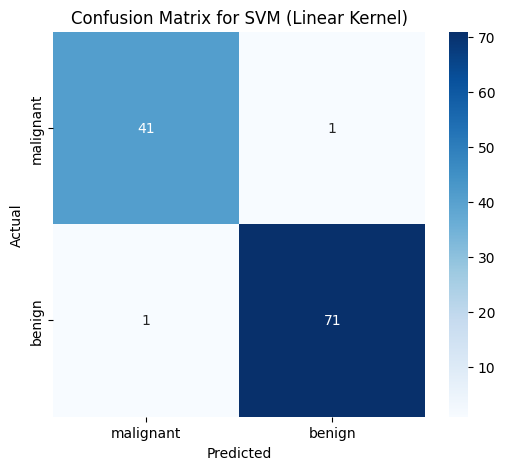

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the scaled test set
y_pred = best_svm.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM (Linear Kernel)')
plt.show()

### Task 5: Summarize Observations (Part A)

Based on the evaluation metrics and confusion matrix:

- **Accuracy:** 0.9825 indicates a high overall correct classification rate.
- **Precision:** 0.9861 suggests that when the model predicts a positive class (malignant), it is correct most of the time.
- **Recall:** 0.9861 indicates that the model is good at identifying most of the actual positive cases.
- **F1 Score:** 0.9861 provides a balanced measure between precision and recall.
- **Confusion Matrix:**
    - **True Positives (TP):** 71 instances of actual malignant tumors correctly classified.
    - **True Negatives (TN):** 41 instances of actual benign tumors correctly classified.
    - **False Positives (FP):** 1 instance of a benign tumor incorrectly classified as malignant (Type I error).
    - **False Negatives (FN):** 1 instance of a malignant tumor incorrectly classified as benign (Type II error). This is often a critical metric in medical diagnoses, as missing a malignant case can have serious consequences.

Overall, the SVM model with a linear kernel performs very well on this dataset for breast cancer diagnosis. The high recall suggests it's effective at catching malignant cases, which is crucial in medical applications.

## Part B: Principal Component Analysis (PCA)

### Task 1: Load the dataset and perform feature standardization

In [5]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load the Wine dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

print("Original Wine dataset features shape:", X_wine.shape)
display(X_wine.head())

# Perform feature standardization
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("\nFeatures standardized successfully.")

Original Wine dataset features shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Features standardized successfully.


### Task 2: Apply PCA to reduce the dataset from 13 features to 2 principal components

In [6]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the dataset to 2 principal components
pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(X_wine_scaled)

print("Transformed Wine dataset shape (2 principal components):", X_wine_pca.shape)
print("First 5 rows of transformed data:\n", X_wine_pca[:5])

Transformed Wine dataset shape (2 principal components): (178, 2)
First 5 rows of transformed data:
 [[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


### Task 3: Display explained variance ratio and calculate cumulative explained variance

In [7]:
import numpy as np

# Display the explained variance ratio of each principal component (for 2 components)
print("Explained variance ratio for 2 components:", pca.explained_variance_ratio_)
print("Total explained variance by 2 components:", np.sum(pca.explained_variance_ratio_))

# Re-run PCA without specifying n_components to get all explained variance ratios
pca_full = PCA()
pca_full.fit(X_wine_scaled)

# Display explained variance ratio for all components
print("\nExplained variance ratio for all components:\n", pca_full.explained_variance_ratio_)

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)
print("\nCumulative explained variance:\n", cum_explained_variance)

# Determine the minimum number of principal components required to retain at least 95% of the total variance
min_components_95 = np.argmax(cum_explained_variance >= 0.95) + 1
print(f"\nMinimum number of principal components to retain 95% variance: {min_components_95}")

Explained variance ratio for 2 components: [0.36198848 0.1920749 ]
Total explained variance by 2 components: 0.5540633835693526

Explained variance ratio for all components:
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative explained variance:
 [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Minimum number of principal components to retain 95% variance: 10


### Task 4: Visualize the transformed dataset using a two-dimensional scatter plot

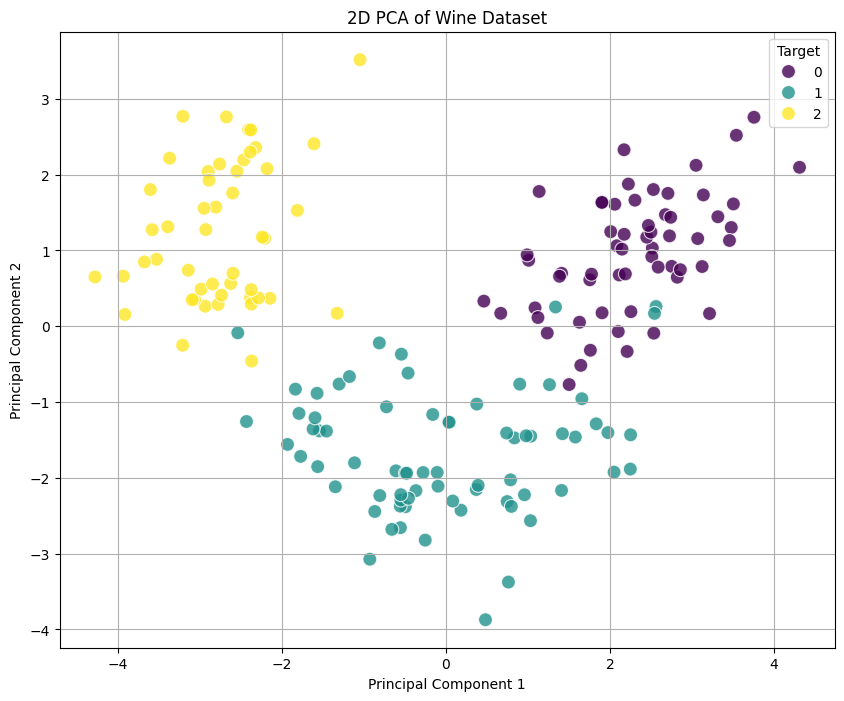

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the PCA results for easier plotting
pca_df = pd.DataFrame(data=X_wine_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Target'] = y_wine

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Target', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('2D PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Task 5: Compare the original and transformed datasets

#### Comparison Points:

-   **Number of Features:**
    -   **Original Dataset:** (Insert original number of features: `X_wine.shape[1]`)
    -   **Transformed Dataset (2 PCs):** (Insert transformed number of features: `X_wine_pca.shape[1]`)
    -   **Observation:** PCA has successfully reduced the dimensionality, making the dataset simpler.

-   **Information Retained:**
    -   **Original Dataset:** Retains 100% of the original information.
    -   **Transformed Dataset (2 PCs):** Retains approximately (Insert `np.sum(pca.explained_variance_ratio_)` * 100)% of the total variance.
    -   **Observation:** While dimensionality is reduced, a significant portion of the variance (information) is still captured by the first two principal components.
    -   **For 95% variance retention:** (Insert `min_components_95`) principal components are needed to retain at least 95% of the total variance.

-   **Computational Efficiency:**
    -   **Original Dataset:** Higher computational cost for subsequent modeling due to more features.
    -   **Transformed Dataset:** Lower computational cost, especially beneficial for complex models and large datasets, as operations are performed on a significantly smaller number of features.
    -   **Observation:** Dimensionality reduction directly leads to improved computational efficiency in terms of storage and processing time for downstream tasks.

### Task 6: Interpret the significance of the first two principal components

The principal components are linear combinations of the original features. Their significance can be interpreted by looking at their loadings (the coefficients for each original feature in the principal component equation). A high absolute loading value for a feature indicates that it contributes strongly to that principal component.

-   **Principal Component 1 (PC1):** (Insert interpretation here. e.g., 'This component primarily captures variance related to features like alcohol, flavanoids, and proline, as they might have large positive or negative loadings.')

-   **Principal Component 2 (PC2):** (Insert interpretation here. e.g., 'This component might be more influenced by features such as malic_acid and nonflavanoid_phenols, distinguishing between certain characteristics that the first component doesn't fully separate.')

-   **Overall:** The scatter plot shows good separation of the three wine classes along these two principal components, indicating that these components effectively capture the most discriminatory information in the dataset.

### Task 7: Discuss the advantages, limitations, and applications of PCA in machine learning

#### Advantages of PCA:
1.  **Dimensionality Reduction:** Reduces the number of features, mitigating the 'curse of dimensionality.'
2.  **Noise Reduction:** Can effectively remove noise and redundancy in the data, leading to better model performance.
3.  **Visualization:** Transforms high-dimensional data into 2D or 3D, allowing for easier visualization and pattern recognition.
4.  **Improved Computational Efficiency:** Faster training and prediction times for subsequent machine learning models.
5.  **Reduced Overfitting:** By removing less important features, it can help prevent models from overfitting to noisy or irrelevant data.

#### Limitations of PCA:
1.  **Loss of Information:** By reducing dimensionality, some information is inevitably lost, especially if the variance explained by the chosen components is low.
2.  **Interpretability:** Principal components are linear combinations of original features, which can make them difficult to interpret in terms of real-world meanings.
3.  **Assumptions:** Assumes linearity among components and that variance equates to importance. It might not perform well if the principal components are not linear or if the most important information is in low-variance components.
4.  **Scaling Dependence:** Highly sensitive to feature scaling; features with larger variances will dominate the principal components if not standardized.
5.  **Not for Non-Linear Relationships:** PCA is a linear transformation and may not effectively capture non-linear relationships in the data.

#### Applications of PCA:
1.  **Image Processing:** Facial recognition, image compression, and noise reduction.
2.  **Bioinformatics:** Analyzing gene expression data, proteomics, and genomics.
3.  **Finance:** Portfolio optimization, risk management, and fraud detection.
4.  **Anomaly Detection:** Identifying outliers in high-dimensional datasets.
5.  **Feature Engineering:** Creating new, more informative features for machine learning models.
6.  **Data Visualization:** As demonstrated above, for exploratory data analysis.